Se importan librerias para el EDA y dataset modificado (object -> interger).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

ruta_train = '/content/drive/My Drive/Training_And_Testing_Dataset/smoking_prediction_processed.csv'
df_train = pd.read_csv(ruta_train)

Mounted at /content/drive


/tmp/ipykernel_2376/2994125376.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='smoking', y='age', palette='Set2', ax=axes[1])


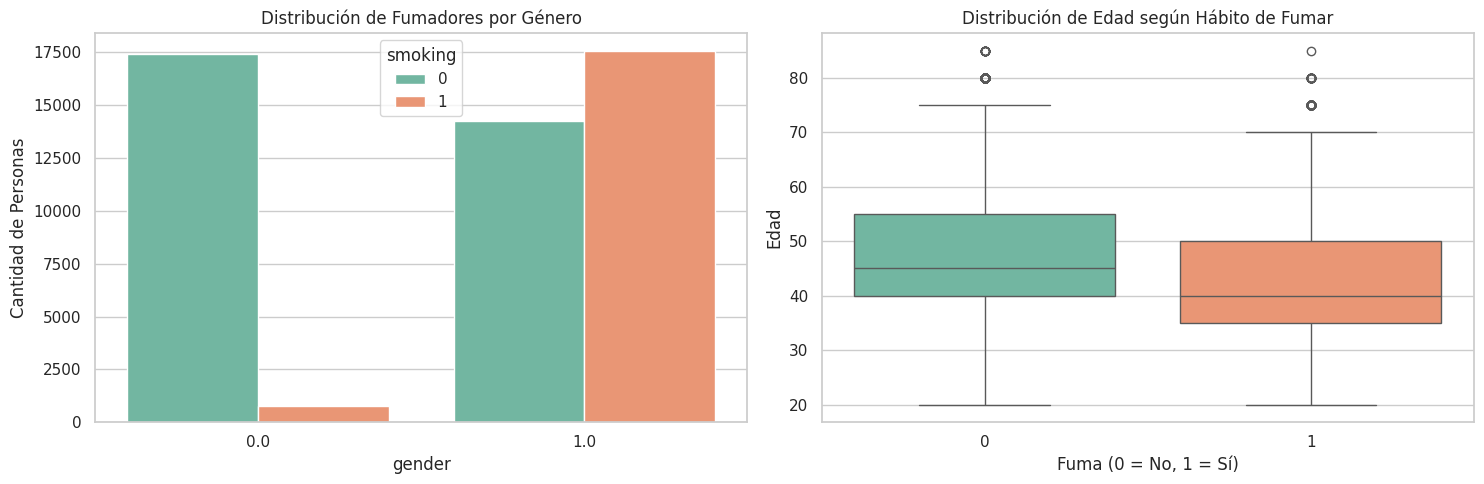

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Gráfico de Barras: Género vs. Fumadores
# Nos dirá si en este dataset fuman más los hombres o las mujeres
sns.countplot(data=df_train, x='gender', hue='smoking', palette='Set2', ax=axes[0])
axes[0].set_title('Distribución de Fumadores por Género')
axes[0].set_ylabel('Cantidad de Personas')

# 2. Gráfico de Cajas (Boxplot): Edad vs. Fumadores
# Nos mostrará en qué rangos de edad se concentra la mayor cantidad de fumadores
sns.boxplot(data=df_train, x='smoking', y='age', palette='Set2', ax=axes[1])
axes[1].set_title('Distribución de Edad según Hábito de Fumar')
axes[1].set_xlabel('Fuma (0 = No, 1 = Sí)')
axes[1].set_ylabel('Edad')

plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   50000 non-null  int64  
 1   gender               50000 non-null  float64
 2   age                  50000 non-null  int64  
 3   height(cm)           50000 non-null  int64  
 4   weight(kg)           50000 non-null  int64  
 5   waist(cm)            50000 non-null  float64
 6   eyesight(left)       50000 non-null  float64
 7   eyesight(right)      50000 non-null  float64
 8   hearing(left)        50000 non-null  float64
 9   hearing(right)       50000 non-null  float64
 10  systolic             50000 non-null  float64
 11  relaxation           50000 non-null  float64
 12  fasting blood sugar  50000 non-null  float64
 13  Cholesterol          50000 non-null  float64
 14  triglyceride         50000 non-null  float64
 15  HDL                  50000 non-null 

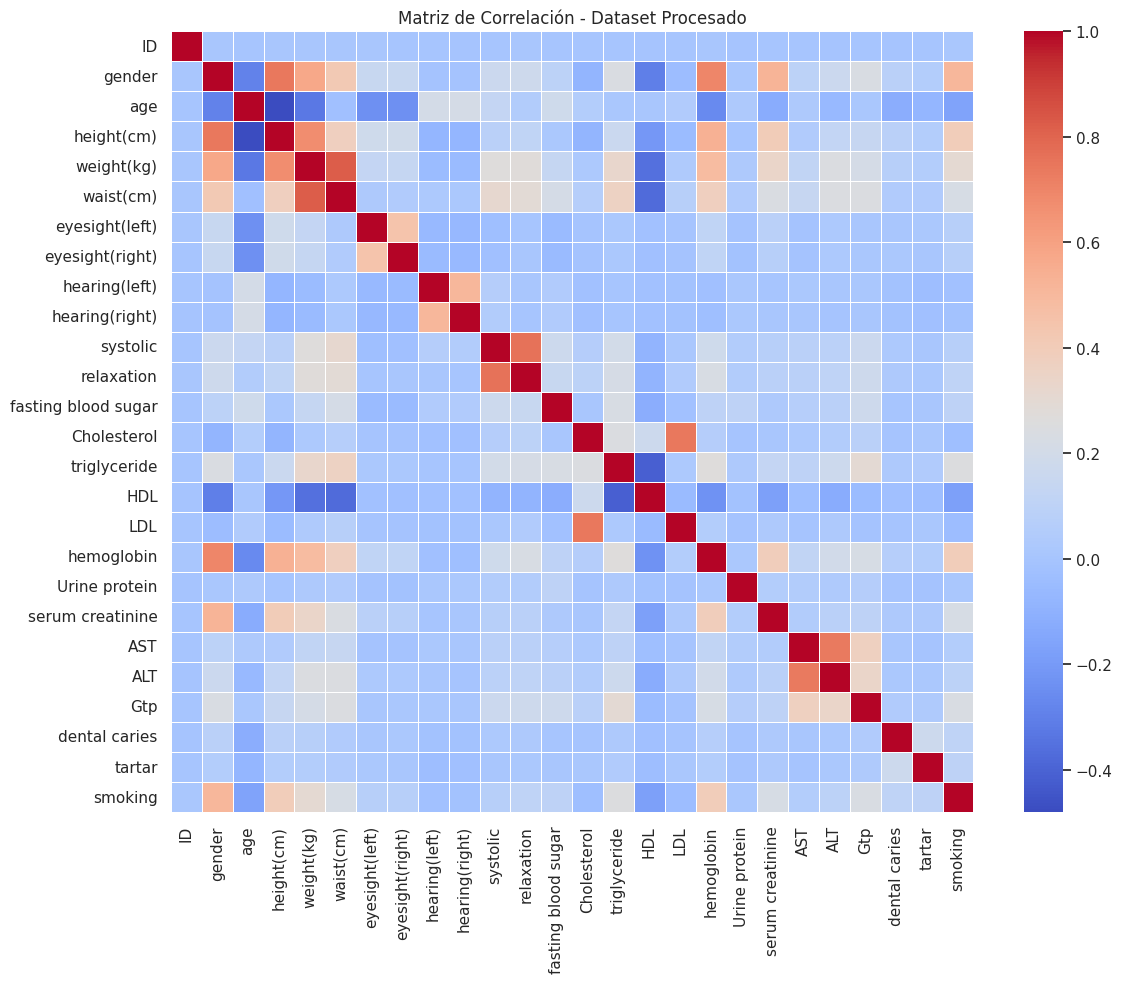

In [5]:
#Inspect the data
print(df_train.info())
print(df_train.head())

# Compute correlation matrix
corr = df_train.corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - Dataset Procesado')
plt.tight_layout()

/tmp/ipykernel_2376/121631951.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Fumador', 'Fumador'])
/tmp/ipykernel_2376/121631951.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Fumador', 'Fumador'])


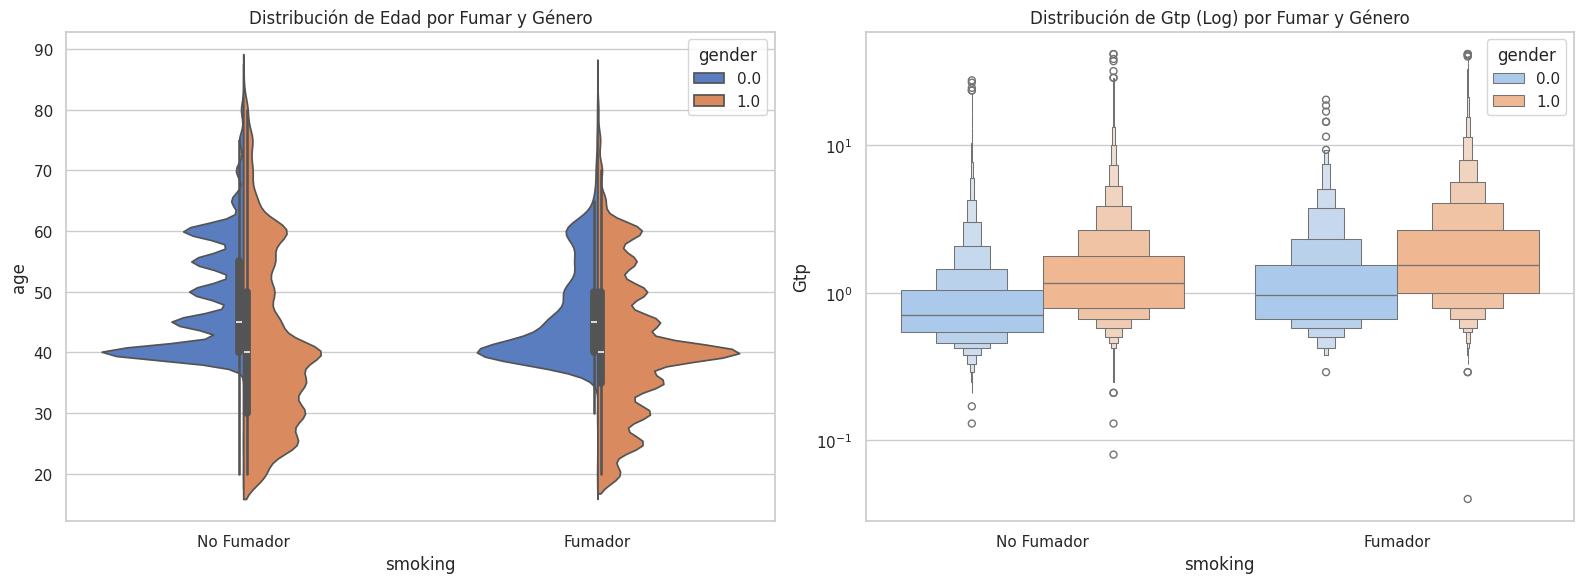

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo para que se vea profesional
sns.set_theme(style="whitegrid")

# Supongamos que tu dataframe se llama 'df' (el que cargaste en el EDA)
# y que tienes 'gender' (0: hombre, 1: mujer) y 'smoking' (0: no, 1: sí)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico de Edad según Fumar y Género
sns.violinplot(data=df_train, x='smoking', y='age', hue='gender', split=True, ax=axes[0], palette='muted')
axes[0].set_title('Distribución de Edad por Fumar y Género')
axes[0].set_xticklabels(['No Fumador', 'Fumador'])

# 2. Gráfico de Gtp según Fumar y Género
# Usamos escala logarítmica si el Gtp tiene muchos valores atípicos (muy común)
sns.boxenplot(data=df_train, x='smoking', y='Gtp', hue='gender', ax=axes[1], palette='pastel')
axes[1].set_yscale('log') # Escala log para ver mejor la diferencia
axes[1].set_title('Distribución de Gtp (Log) por Fumar y Género')
axes[1].set_xticklabels(['No Fumador', 'Fumador'])

plt.tight_layout()
plt.show()

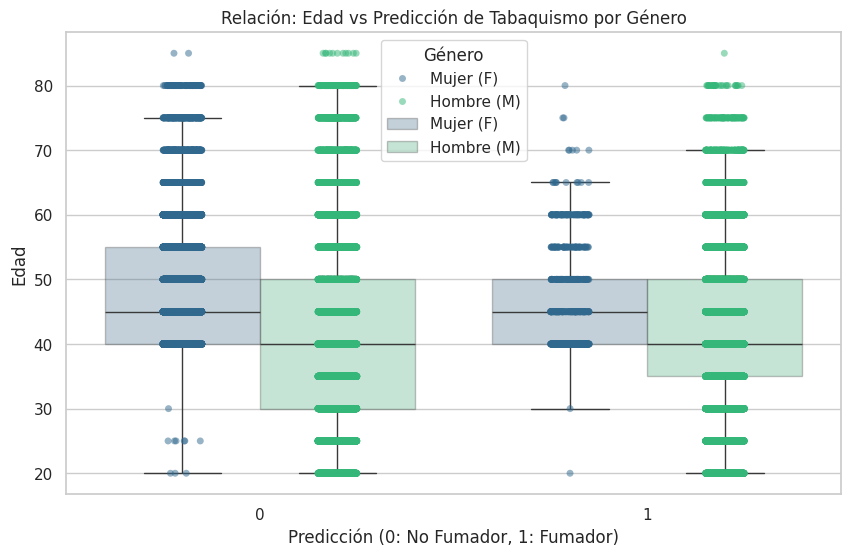

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definimos el mapa de nombres para los gráficos
mapeo_genero = {0: 'Mujer (F)', 1: 'Hombre (M)'}
df_train['genero_desc'] = df_train['gender'].map(mapeo_genero)

# Configuramos el gráfico
plt.figure(figsize=(10, 6))

# Usamos stripplot para ver la distribución de puntos
# Añadimos un pequeño "jitter" para que los puntos no se amontonen
sns.stripplot(data=df_train,
              x='smoking',
              y='age',
              hue='genero_desc',
              dodge=True,
              alpha=0.5,
              palette='viridis')

# Añadimos un boxplot por detrás para ver las medianas claramente
sns.boxplot(data=df_train,
            x='smoking',
            y='age',
            hue='genero_desc',
            palette='viridis',
            showfliers=False,
            boxprops=dict(alpha=0.3))

plt.title('Relación: Edad vs Predicción de Tabaquismo por Género')
plt.xlabel('Predicción (0: No Fumador, 1: Fumador)')
plt.ylabel('Edad')
plt.legend(title='Género')
plt.show()